Цель работы:
Научиться реализовывать один из простых алгоритмов обработки
изображений.

Задание:
1. Реализовать программу согласно варианту задания. Базовый алгоритм,
используемый в программе, необходимо реализовать в 2 вариантах: с
использованием встроенных функций какой-либо библиотеки (OpenCV,
PIL и др.) и нативно на Python или C++.
2. Сравнить быстродействие реализованных вариантов.
3. Сделать отчёт в виде readme на GitHub, там же должен быть выложен
исходный код.

Варианты:
1. Фильтр Собеля.
2. Бинаризация с адаптивным порогом (по выбору – mean или gaussian)
3. **Усредняющий фильтр Гаусса с переменным размером ядра и
параметрами гауссианы.**
4. Медианный фильтр с переменным размером ядра.
5. Chroma key. Заданы два изображения и цвет (интервал задается
пользователем). Заменить все соответствующие заданному цвету области
одного изображения на второе изображение.
6. Дилатация, примитив размера 3 на 3, бинаризацию можно не
реализовывать вручную.
7. Эрозия, примитив размера 3 на 3, бинаризацию можно не реализовывать
вручную.

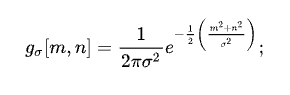

In [5]:
import numpy as np
import math

In [16]:
def computeGausKernel(kernel_size, sigma):
  if (kernel_size % 2 == 0):
    return

  gaus = np.zeros((kernel_size, kernel_size))
  for n in range(kernel_size):
    for m in range(kernel_size):
      gaus[n][m] = 1 / (2 * np.pi * math.pow(sigma, 2)) * math.pow(math.e, -1/2 * ((m-kernel_size//2)**2 + (n-kernel_size//2)**2)/(sigma**2))

  gaus = gaus / np.sum(gaus)
  return gaus

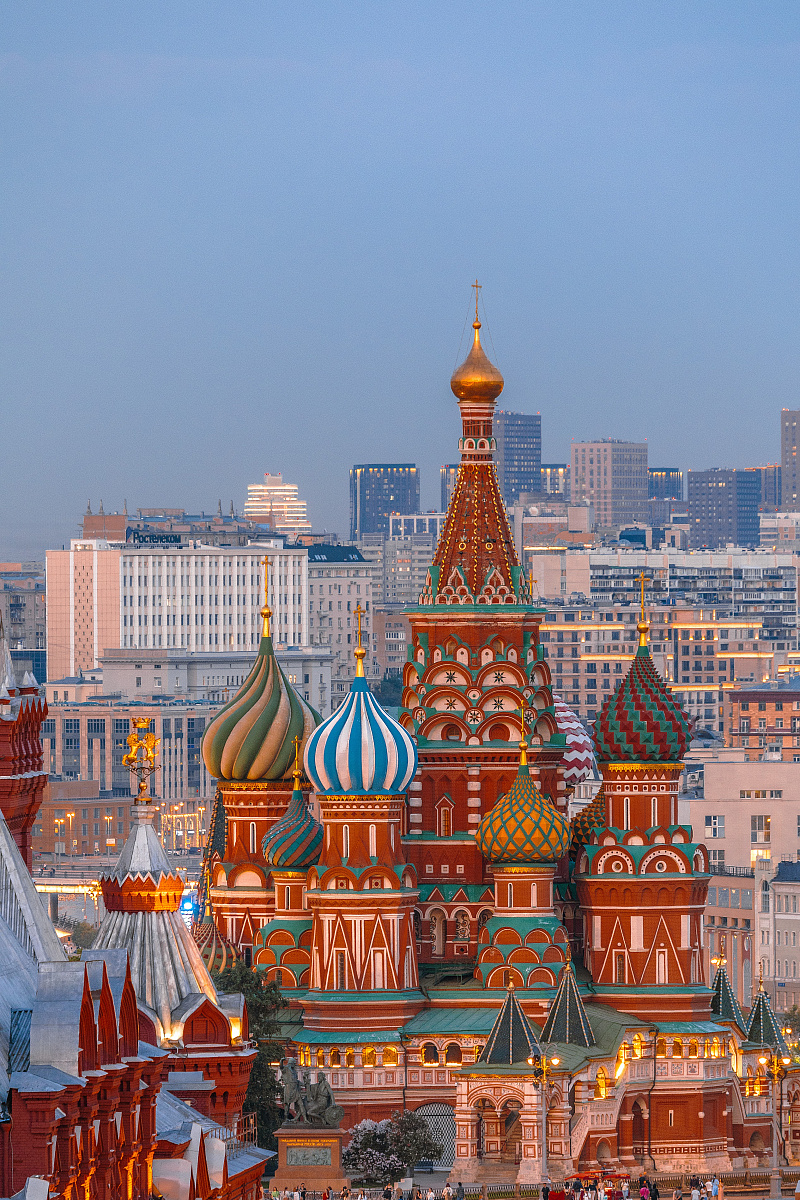

In [3]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/moscow_image.jpg')

cv2_imshow(img)

Линейная пространственная фильтрация

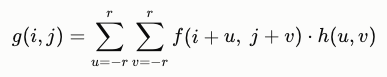

Здесь f — исходное изображение, h — ядро, r — радиус ядра (kernel_size // 2), а u, v — те самые координаты от −r до r

In [65]:
blue = img[..., 0].astype(float)
green = img[..., 1].astype(float)
red = img[..., 2].astype(float)

In [63]:
def convolution(matr, kernel):
  res_matrix = np.empty((matr.shape[0], matr.shape[1]))
  kernel_size = kernel.shape[0]

  # новые размеры увеличенной матрицы
  new_n = matr.shape[0] + kernel_size//2 * 2
  new_m = matr.shape[1] + kernel_size//2 * 2

  matr_framed = np.zeros((new_n, new_m))

  matr_framed[kernel_size//2 : (new_n-kernel_size//2), kernel_size//2 : (new_m-kernel_size//2)] = matr

  for i in range(matr.shape[0]):
    for j in range(matr.shape[1]):
      window = matr_framed[i:i+kernel_size, j:j+kernel_size]
      multi = window * kernel

      res_matrix[i][j] = multi.sum()

  return res_matrix

In [66]:
image_kernel = computeGausKernel(15, 5)

In [67]:
conv_red = convolution(red, image_kernel)
conv_green = convolution(green, image_kernel)
conv_blue = convolution(blue, image_kernel)

In [68]:
filtered_image= np.stack((conv_blue, conv_green, conv_red), axis=2)
filtered_image = np.round(filtered_image).astype(np.uint8)

Из библиотеки Open CV

In [69]:
cv_image = cv2.GaussianBlur(img, (15, 15), 5)

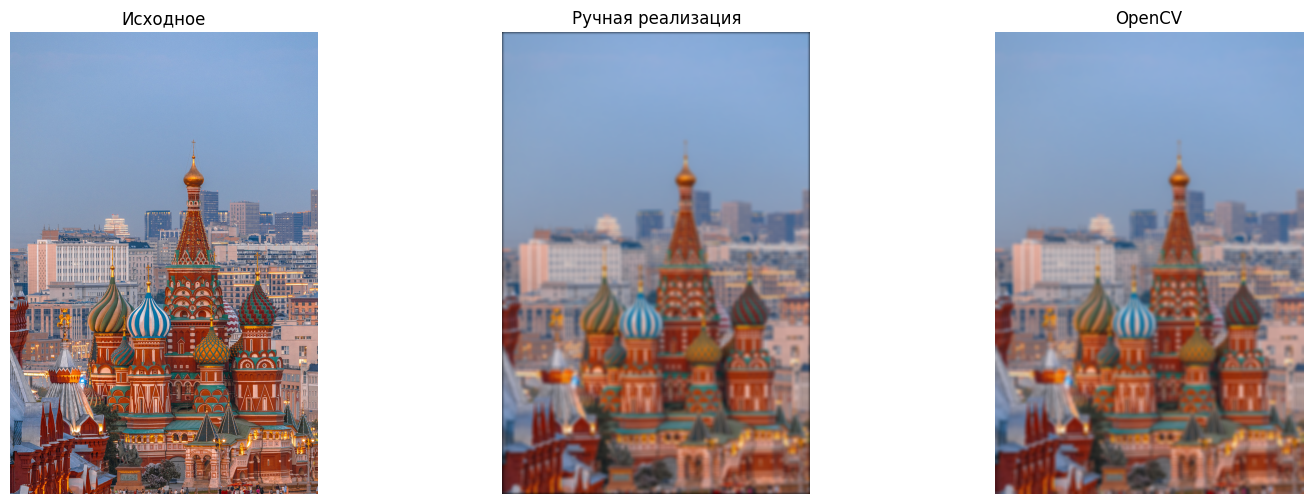

In [71]:
import time
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Исходное', 'Ручная реализация', 'OpenCV']
for ax, im, title in zip(axes, [img, filtered_image, cv_image], titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.show()

k=3: вручную 1.710 с, OpenCV 0.00028 с
k=5: вручную 0.853 с, OpenCV 0.00058 с
k=9: вручную 0.870 с, OpenCV 0.00105 с
k=15: вручную 0.997 с, OpenCV 0.00131 с
k=21: вручную 1.108 с, OpenCV 0.00197 с


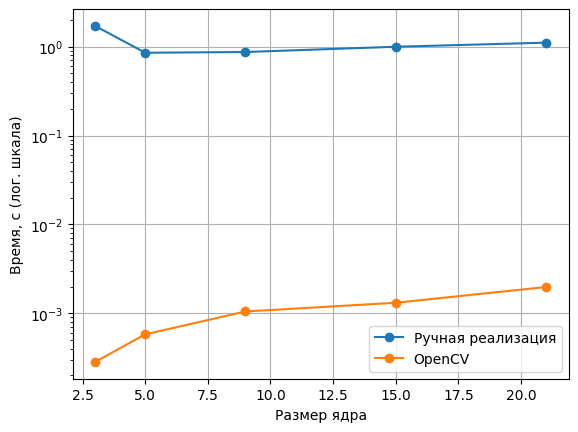

In [72]:
def manual_gaussian_blur(image, kernel_size, sigma):
    kernel = computeGausKernel(kernel_size, sigma)
    channels = [convolution(image[..., c].astype(float), kernel) for c in range(3)]
    return np.round(np.stack(channels, axis=2)).astype(np.uint8)

small = cv2.resize(img, (img.shape[1] // 4, img.shape[0] // 4))

sizes = [3, 5, 9, 15, 21]
manual_times, cv_times = [], []

for k in sizes:
    sigma = k / 3  # примерно по правилу «радиус ≈ 3σ»

    start = time.perf_counter()
    manual_gaussian_blur(small, k, sigma)
    manual_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    cv2.GaussianBlur(small, (k, k), sigma)
    cv_times.append(time.perf_counter() - start)

    print(f'k={k}: вручную {manual_times[-1]:.3f} с, OpenCV {cv_times[-1]:.5f} с')

plt.plot(sizes, manual_times, 'o-', label='Ручная реализация')
plt.plot(sizes, cv_times, 'o-', label='OpenCV')
plt.yscale('log')
plt.xlabel('Размер ядра')
plt.ylabel('Время, с (лог. шкала)')
plt.legend()
plt.grid(True)
plt.show()